# Pix2Pix Inference Demo

Run inference locally with a trained checkpoint.  
Requires: a checkpoint file (`checkpoints/best.pt`) and test images under `data/raw/maps/test/`.

In [4]:
import sys, os
from pathlib import Path

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Auto-locate the repo in common Colab/Drive locations
candidates = [
    Path('/content/CV2_Final_Project-1'),
    Path('/content/drive/MyDrive/CV2_Final_Project-1'),
    Path('/content/drive/MyDrive/Colab Notebooks/CV2_Final_Project-1'),
]

PROJECT_ROOT = next(
    (p for p in candidates if (p / 'requirements.txt').exists()),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Could not find project folder. Set PROJECT_ROOT manually to the folder containing requirements.txt'
    )

os.chdir(PROJECT_ROOT)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("src/ on path:", str(SRC_DIR) in sys.path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/CV2_Final_Project-1
src/ on path: True


In [5]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from pix2pix_project.models.pix2pix import build_generator

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT = PROJECT_ROOT / "checkpoints" / "best.pt"
TEST_DIR = PROJECT_ROOT / "data" / "raw" / "maps" / "test"

print(f"Device: {DEVICE}")
print(f"Checkpoint exists: {CHECKPOINT.exists()}")
print(f"Test dir exists: {TEST_DIR.exists()}")

Device: cuda
Checkpoint exists: True
Test dir exists: True


## Load Generator

In [6]:
generator = build_generator(in_channels=3, out_channels=3, features=64).to(DEVICE)

state = torch.load(CHECKPOINT, map_location=DEVICE)
if isinstance(state, dict) and "generator" in state:
    generator.load_state_dict(state["generator"])
else:
    generator.load_state_dict(state)
generator.eval()
print("Generator loaded successfully.")

Generator loaded successfully.


## Run Inference on Sample Images

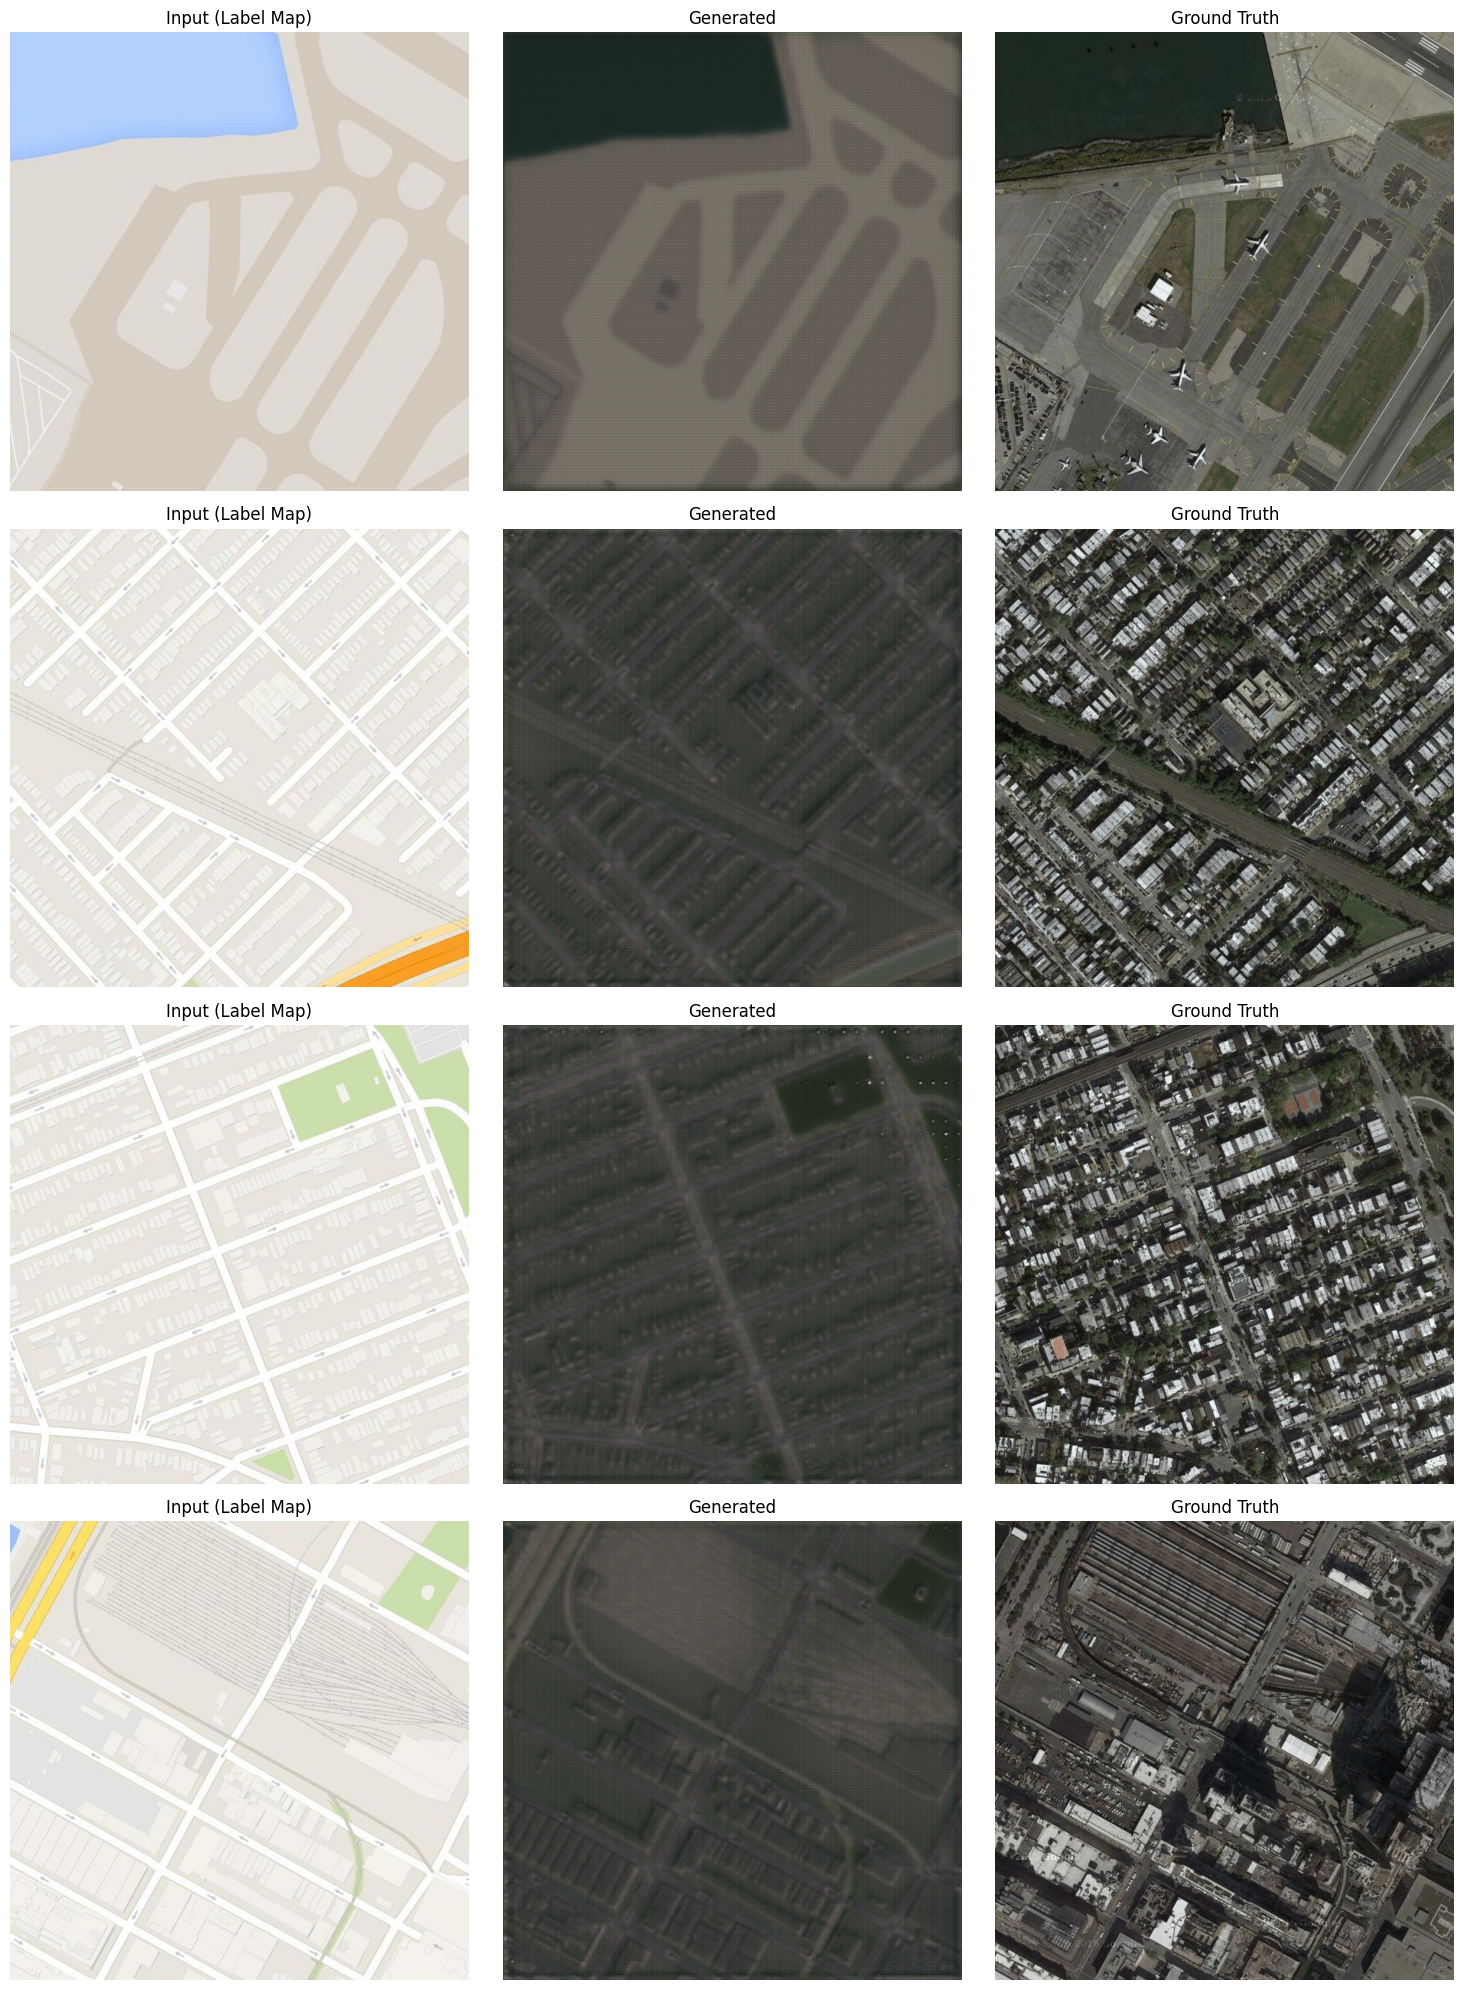

In [7]:
def load_paired_image(path):
    """Split a pix2pix paired image into (label_map, real_image)."""
    img = Image.open(path).convert("RGB")
    w, h = img.size
    real = img.crop((0, 0, w // 2, h))
    label = img.crop((w // 2, 0, w, h))
    return label, real


def preprocess(image):
    """Convert PIL image to model input tensor (normalized to [-1, 1])."""
    arr = np.array(image).astype(np.float32) / 255.0
    arr = arr * 2.0 - 1.0
    return torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(DEVICE)


def postprocess(tensor):
    """Convert model output tensor back to PIL image."""
    arr = tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    arr = ((arr * 0.5 + 0.5) * 255.0).clip(0, 255).astype(np.uint8)
    return Image.fromarray(arr)


# Collect test images
test_images = sorted([
    p for p in TEST_DIR.glob("*")
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
])
NUM_SAMPLES = min(4, len(test_images))

fig, axes = plt.subplots(NUM_SAMPLES, 3, figsize=(15, 5 * NUM_SAMPLES))
if NUM_SAMPLES == 1:
    axes = axes[np.newaxis, :]

for i in range(NUM_SAMPLES):
    label, real = load_paired_image(test_images[i])
    inp = preprocess(label)
    with torch.no_grad():
        pred = generator(inp).clamp(-1, 1)
    pred_img = postprocess(pred)

    axes[i, 0].imshow(label)
    axes[i, 0].set_title("Input (Label Map)")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(pred_img)
    axes[i, 1].set_title("Generated")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(real)
    axes[i, 2].set_title("Ground Truth")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()